In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Important: We use '../' because the notebook is in the 'notebooks' folder
metadata_path = '../data/metadata.csv'

if os.path.exists(metadata_path):
    df = pd.read_csv(metadata_path)
    print(f" Data loaded successfully! Analying {len(df)} images.")
else:
    print("Error: metadata.csv not found. Please run src/scraper.py and src/processor.py first.")

# Show the first few rows of your new professional data structure
df.head()

 Data loaded successfully! Analying 20 images.


,title,local_path,brightness,file_size_kb,processed_path
0,A Light in the Attic,/Users/msreeja/Documents/ecommerce-image-intel...,216.119417,9.644531,/Users/msreeja/Documents/ecommerce-image-intel...
1,Tipping the Velvet,/Users/msreeja/Documents/ecommerce-image-intel...,57.219350,6.928711,/Users/msreeja/Documents/ecommerce-image-intel...
2,Soumission,/Users/msreeja/Documents/ecommerce-image-intel...,225.045250,3.966797,/Users/msreeja/Documents/ecommerce-image-intel...
3,Sharp Objects,/Users/msreeja/Documents/ecommerce-image-intel...,23.675933,8.244141,/Users/msreeja/Documents/ecommerce-image-intel...
4,Sapiens: A Brief History of Humankind,/Users/msreeja/Documents/ecommerce-image-intel...,235.403167,7.798828,/Users/msreeja/Documents/ecommerce-image-intel...


In [ ]:
print("----E-commerce Image Intelligence Report ----")
print(f"Total Products Scraped: {len(df)}")
print(f"Average Cover Brightness: {df['brightness'].mean():.2f}")
print(f"Total Storage Used: {df['file_size_kb'].sum():.2f} KB")

# Identify outliers
brightest_book = df.loc[df['brightness'].idxmax()]
darkest_book = df.loc[df['brightness'].idxmin()]

print(f"\n Brightest Cover: {brightest_book['title']} ({brightest_book['brightness']:.2f})")
print(f" Darkest Cover: {darkest_book['title']} ({darkest_book['brightness']:.2f})")

--- E-commerce Image Intelligence Report ---
Total Products Scraped: 20
Average Cover Brightness: 127.77
Total Storage Used: 173.05 KB

 Brightest Cover: Sapiens: A Brief History of Humankind (235.40)
 Darkest Cover: The Black Maria (11.31)


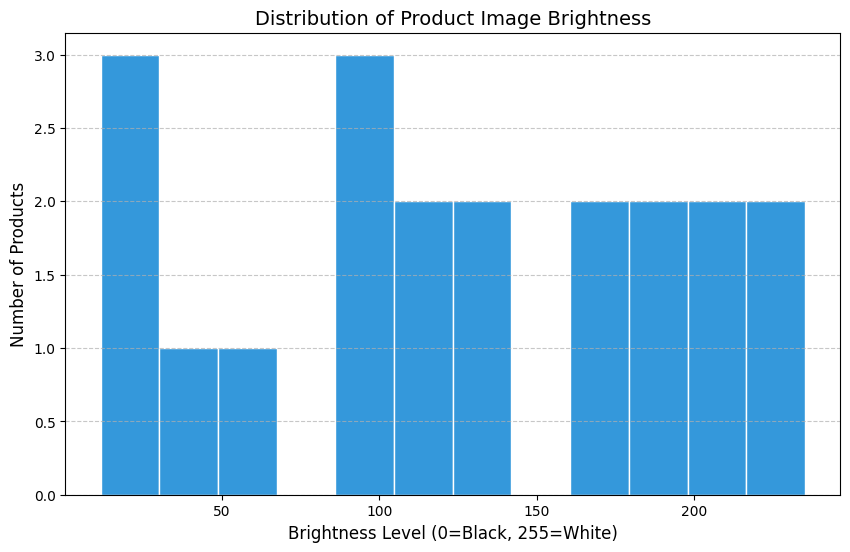

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df['brightness'], bins=12, color='#3498db', edgecolor='white')

plt.title("Distribution of Product Image Brightness", fontsize=14)
plt.xlabel("Brightness Level (0=Black, 255=White)", fontsize=12)
plt.ylabel("Number of Products", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

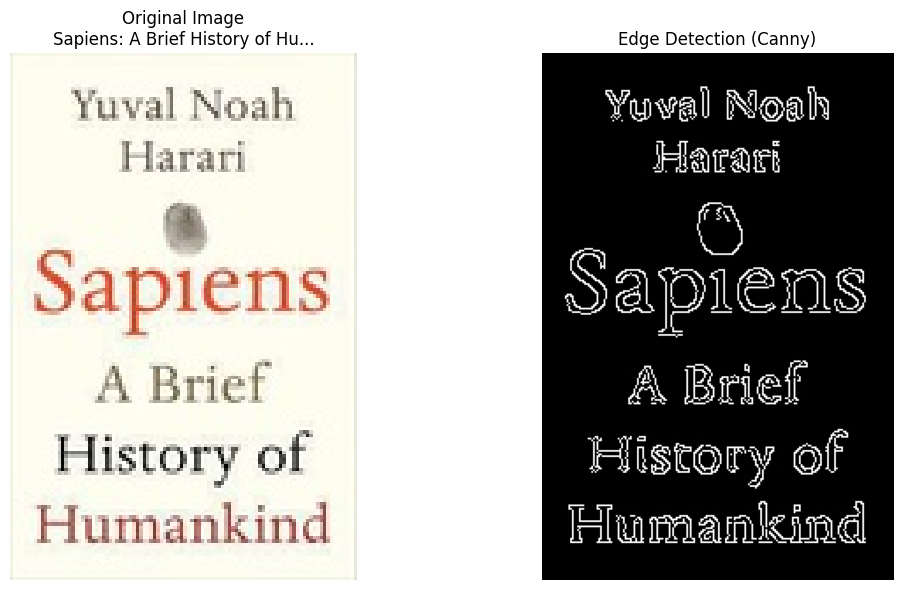

In [13]:
# Select a sample (e.g., the 5th book)
sample_index = 4 
sample_row = df.iloc[sample_index]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display Raw Image
raw_img = Image.open(sample_row['local_path'])
axes[0].imshow(raw_img)
axes[0].set_title(f"Original Image\n{sample_row['title'][:30]}...")
axes[0].axis('off')

# Display Processed Image (Edges)
proc_img = Image.open(sample_row['processed_path'])
axes[1].imshow(proc_img, cmap='gray')
axes[1].set_title("Edge Detection (Canny)")
axes[1].axis('off')

plt.tight_layout()
plt.show()